In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.datasets import fashion_mnist
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics.pairwise import cosine_similarity

# Load model
full_model = load_model("models/fashion_cnn.keras")

# Keras 3 compatible feature extractor
@tf.function
def extract_features(x):
    for layer in full_model.layers:
        x = layer(x)
        if layer.name == "flatten":
            return x
    return x

# Test
dummy    = np.zeros((1, 28, 28, 1), dtype=np.float32)
test_out = extract_features(dummy)
print("✅ Feature extractor output shape:", test_out.shape)


✅ Feature extractor output shape: (1, 1600)


In [2]:
(_, _), (X_test, y_test) = fashion_mnist.load_data()

class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

X_catalog = (X_test / 255.0).reshape(-1, 28, 28, 1).astype(np.float32)

print("Extracting embeddings for 10,000 catalog images...")
batch_size = 256
embeddings = []

for i in range(0, len(X_catalog), batch_size):
    batch = X_catalog[i:i+batch_size]
    feats = extract_features(batch)
    embeddings.append(feats.numpy())
    if i % 2000 == 0:
        print(f"  {i}/{len(X_catalog)} done...")

catalog_embeddings = np.vstack(embeddings)
print(f"\n✅ Catalog embeddings shape: {catalog_embeddings.shape}")


Extracting embeddings for 10,000 catalog images...
  0/10000 done...

✅ Catalog embeddings shape: (10000, 1600)


In [3]:
np.save("models/catalog_embeddings.npy", catalog_embeddings)
np.save("models/catalog_labels.npy", y_test)

print("✅ Saved:")
print("   models/catalog_embeddings.npy →", catalog_embeddings.shape)
print("   models/catalog_labels.npy     →", y_test.shape)


✅ Saved:
   models/catalog_embeddings.npy → (10000, 1600)
   models/catalog_labels.npy     → (10000,)


In [4]:
def preprocess_image(img):
    img_gray  = img.convert("L").resize((28, 28))
    img_array = np.array(img_gray)
    if img_array.mean() > 127:
        img_gray  = ImageOps.invert(img_gray)
        img_array = np.array(img_gray)
    return (img_array / 255.0).astype(np.float32)

def visual_search(query_img, top_k=5):
    arr          = preprocess_image(query_img).reshape(1, 28, 28, 1)
    query_embed  = extract_features(arr).numpy()
    similarities = cosine_similarity(query_embed, catalog_embeddings)[0]
    top_indices  = similarities.argsort()[-top_k-1:][::-1][:top_k]

    return [{
        "index"      : int(idx),
        "label"      : class_names[y_test[idx]],
        "similarity" : float(similarities[idx]),
        "image"      : X_test[idx]
    } for idx in top_indices]

print("✅ visual_search() ready")


✅ visual_search() ready


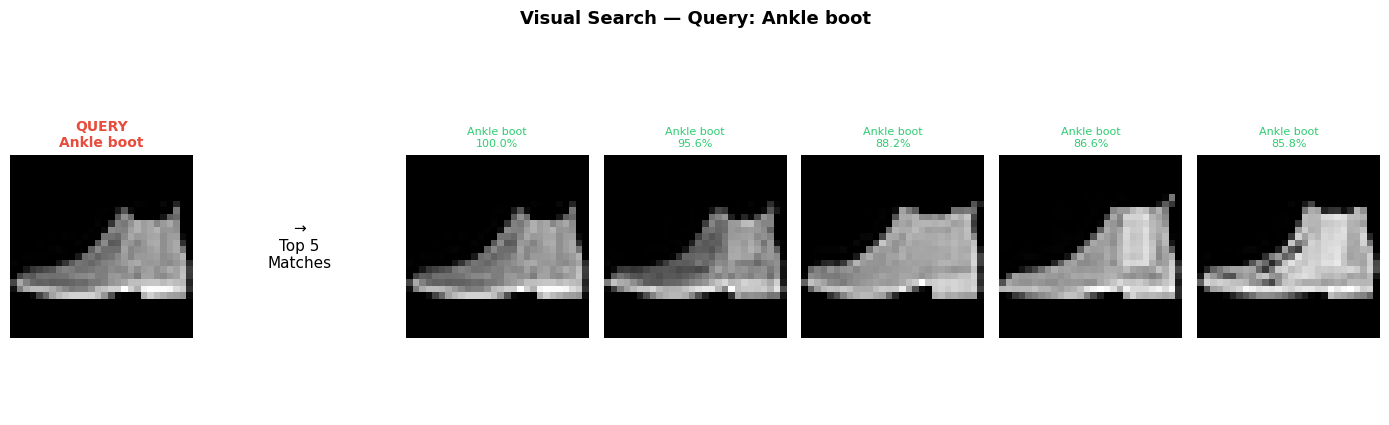


Query: Ankle boot
  1. Ankle boot   — 100.0%
  2. Ankle boot   — 95.6%
  3. Ankle boot   — 88.2%
  4. Ankle boot   — 86.6%
  5. Ankle boot   — 85.8%


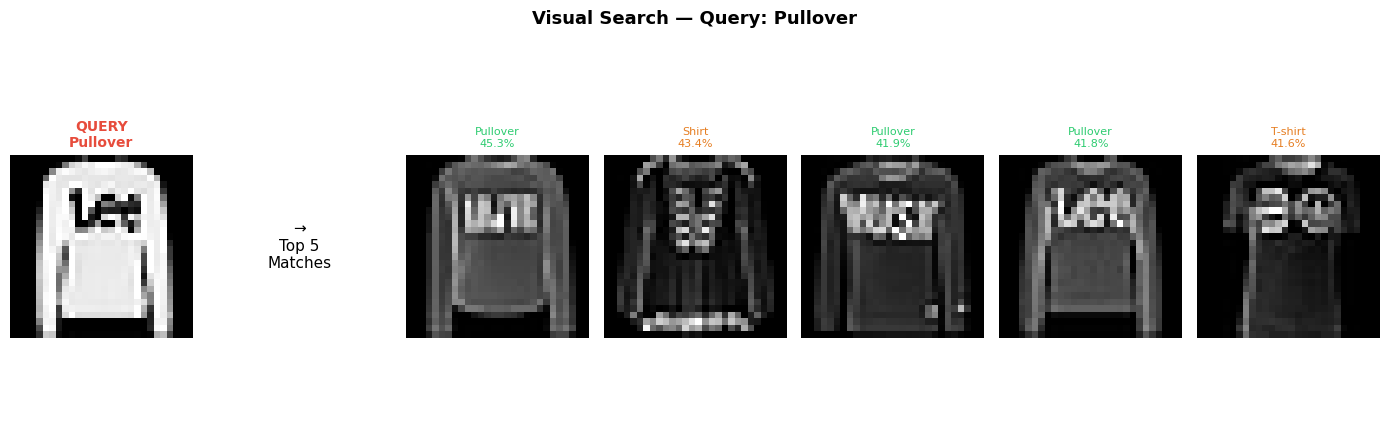


Query: Pullover
  1. Pullover     — 45.3%
  2. Shirt        — 43.4%
  3. Pullover     — 41.9%
  4. Pullover     — 41.8%
  5. T-shirt      — 41.6%


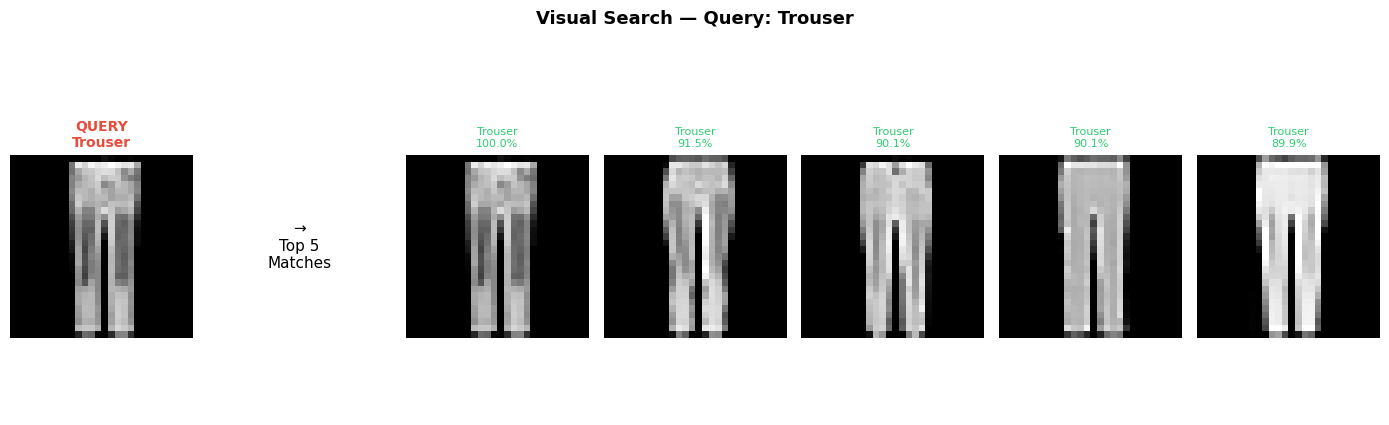


Query: Trouser
  1. Trouser      — 100.0%
  2. Trouser      — 91.5%
  3. Trouser      — 90.1%
  4. Trouser      — 90.1%
  5. Trouser      — 89.9%


In [5]:
def show_visual_search(query_idx, top_k=5):
    query_img   = Image.fromarray(X_test[query_idx])
    query_label = class_names[y_test[query_idx]]
    results     = visual_search(query_img, top_k=top_k)

    fig = plt.figure(figsize=(14, 4))
    gs  = gridspec.GridSpec(1, top_k + 2)

    ax_query = fig.add_subplot(gs[0, 0])
    ax_query.imshow(X_test[query_idx], cmap="gray")
    ax_query.set_title(f"QUERY\n{query_label}", fontsize=10,
                       fontweight="bold", color="#e74c3c")
    ax_query.axis("off")

    ax_arrow = fig.add_subplot(gs[0, 1])
    ax_arrow.text(0.5, 0.5, "→\nTop 5\nMatches",
                  ha="center", va="center", fontsize=11,
                  transform=ax_arrow.transAxes)
    ax_arrow.axis("off")

    for i, result in enumerate(results):
        ax = fig.add_subplot(gs[0, i + 2])
        ax.imshow(result["image"], cmap="gray")
        color = "#2ecc71" if result["label"] == query_label else "#e67e22"
        ax.set_title(f"{result['label']}\n{result['similarity']:.1%}",
                     fontsize=8, color=color)
        ax.axis("off")

    plt.suptitle(f"Visual Search — Query: {query_label}",
                 fontsize=13, fontweight="bold", y=1.05)
    plt.tight_layout()
    plt.savefig(f"visual_search_{query_label.lower().replace(' ', '_')}.png",
                dpi=150, bbox_inches="tight")
    plt.show()

    print(f"\nQuery: {query_label}")
    for i, r in enumerate(results):
        print(f"  {i+1}. {r['label']:12} — {r['similarity']:.1%}")

# Test on 3 categories
show_visual_search(0)    # Ankle boot
show_visual_search(1)    # Pullover
show_visual_search(15)   # Trouser
